In [3]:
# The unique dataset UUID for the Catalogue of Life in GBIF
COL_DATASET_KEY = "7ddf754f-d193-4cc9-b351-99906754a03b"

# Search for the name within the CoL dataset
search_results = pygbif.species.name_lookup(
    q="Vespa velutina", 
    datasetKey=COL_DATASET_KEY,
    limit=5
)

# Parse and print the results
if search_results and 'results' in search_results:
    for record in search_results['results']:
        print(f"Scientific Name: {record.get('scientificName')}")
        print(f"GBIF Taxon Key:  {record.get('key')}")       # Internal GBIF reference
        print(f"Official CoL ID: {record.get('taxonID')}")   # Native Catalogue of Life ID
        print(f"Rank:           {record.get('rank')}")
        print(f"Status:         {record.get('status')}")
        print("-" * 40)
else:
    print("No matches found.")

Scientific Name: Vespa velutina Lepeletier, 1836
GBIF Taxon Key:  296612081
Official CoL ID: 7G3C6
Rank:           SPECIES
Status:         None
----------------------------------------
Scientific Name: Vespa velutina f. auraria
GBIF Taxon Key:  314459349
Official CoL ID: FQM3Q
Rank:           FORM
Status:         None
----------------------------------------
Scientific Name: Vespa velutina f. floresiana
GBIF Taxon Key:  314459344
Official CoL ID: TPRYH
Rank:           FORM
Status:         None
----------------------------------------
Scientific Name: Vespa velutina f. variana
GBIF Taxon Key:  314459341
Official CoL ID: TPRZB
Rank:           FORM
Status:         None
----------------------------------------
Scientific Name: Vespa velutina f. timorensis
GBIF Taxon Key:  314459342
Official CoL ID: TPRZ5
Rank:           FORM
Status:         None
----------------------------------------


In [4]:
search_results = pygbif.species.name_lookup(
    q="Vespa velutina", 
    datasetKey=COL_DATASET_KEY,
    status="ACCEPTED",  # Ignores synonyms and doubtful names
    limit=5
)
search_results

{'offset': 0,
 'limit': 5,
 'endOfRecords': False,
 'count': 23,
 'results': [{'key': 296612081,
   'datasetKey': '7ddf754f-d193-4cc9-b351-99906754a03b',
   'nubKey': 1311477,
   'parentKey': 296612032,
   'parent': 'Vespa',
   'kingdom': 'Animalia',
   'phylum': 'Arthropoda',
   'order': 'Hymenoptera',
   'family': 'Vespidae',
   'genus': 'Vespa',
   'species': 'Vespa velutina',
   'kingdomKey': 296374190,
   'phylumKey': 296374886,
   'classKey': 296434567,
   'orderKey': 296455055,
   'familyKey': 307388955,
   'genusKey': 296612032,
   'speciesKey': 296612081,
   'scientificName': 'Vespa velutina Lepeletier, 1836',
   'canonicalName': 'Vespa velutina',
   'authorship': 'Lepeletier, 1836',
   'publishedIn': "Lepeletier, A. L. M. (1836) Histoire Naturelle des Insectes. Hymenopteres. Vol. 1. Roret's Suites a Buffon, Paris, 547 pp.",
   'nameType': 'SCIENTIFIC',
   'taxonomicStatus': 'ACCEPTED',
   'rank': 'SPECIES',
   'origin': 'SOURCE',
   'numDescendants': 0,
   'numOccurrences': 0

In [7]:
from pygbif import species

COL_DATASET_KEY = "7ddf754f-d193-4cc9-b351-99906754a03b"
target_col_id = "7G3C6"

print(f"Translating CoL ID '{target_col_id}'...")

# Use name_usage with sourceId to fetch the exact record by its native ID
lookup_result = species.name_usage(
    datasetKey=COL_DATASET_KEY,
    sourceId=target_col_id
)

# name_usage returns the list of results directly inside the 'results' key
if lookup_result and lookup_result.get('results'):
    taxon_record = lookup_result['results'][0]
    gbif_backbone_key = taxon_record.get('nubKey')
    scientific_name = taxon_record.get('scientificName')
    
    if gbif_backbone_key:
        print(f"→ Successfully mapped '{scientific_name}' to GBIF Key: {gbif_backbone_key}")
        # Proceed to occurrences.search here...
    else:
        print("⚠️ The CoL ID exists, but it does not have a mapped backbone key in GBIF.")
else:
    print("❌ Could not find that CoL ID within the Catalogue of Life dataset.")

Translating CoL ID '7G3C6'...
→ Successfully mapped 'Vespa velutina Lepeletier, 1836' to GBIF Key: 1311477


In [12]:
from pygbif import occurrences

# Define your bounding box coordinates
min_lat, max_lat = 50.621588, 51.566827    # e.g., roughly France
min_lon, max_lon = 2.466355, 6.099105

# Search using coordinate ranges
results = occurrences.search(key = 1311477,
    decimalLatitude=f"{min_lat},{max_lat}",
    decimalLongitude=f"{min_lon},{max_lon}",
    hasCoordinate=True,  # Ensures you only get records with mapped locations
)

print(f"Total records found in box: {results.get('count')}")

Total records found in box: 65768210


In [13]:
results = occurrences.search(key = "7G3C6",
    decimalLatitude=f"{min_lat},{max_lat}",
    decimalLongitude=f"{min_lon},{max_lon}",
    hasCoordinate=True,  # Ensures you only get records with mapped locations
)

print(f"Total records found in box: {results.get('count')}")

Total records found in box: 65768210


# Converting to bmd cube

In [121]:
import pandas as pd
import geopandas as gpd
from bmc.datasource.gbif import harmonisation

bbox = [6.365693, 50.50134, 6.472005, 50.650193]
gbif_table = pd.read_csv("0002756-260623161305970.csv", sep="\t")
gbif_table['geometry'] = gbif_table['eeacellcode'].apply(harmonisation.parse_to_polygon)

# 3. Convert to a GeoDataFrame and set the standard EEA CRS
gdf = gpd.GeoDataFrame(gbif_table, geometry='geometry', crs="EPSG:3035")

# Check the results
print(gdf.head())
print(f"Current CRS: {gdf.crs}")

                             scientificname  year  month  day countrycode  \
0                   Limnephilus Leach, 1815  2024     11    2          DE   
1                                Lycaenidae  2020      6   20          DE   
2  Tischeria ekebladella (Bjerkander, 1795)  2024      9   18          DE   
3             Potamophylax Wallengren, 1891  2021      8   22          DE   
4        Cabera exanthemata (Scopoli, 1763)  2023      6    4          DE   

          eeacellcode  occurrences  distinctobservers  \
0  250mE406950N306375            1                  1   
1  250mE406450N305425            1                  1   
2  250mE407125N306375            1                  1   
3  250mE406350N305700            1                  1   
4  250mE406525N305500            1                  1   

                                            geometry  
0  POLYGON ((4069750 3063750, 4069750 3064000, 40...  
1  POLYGON ((4064750 3054250, 4064750 3054500, 40...  
2  POLYGON ((4071500 3063750,

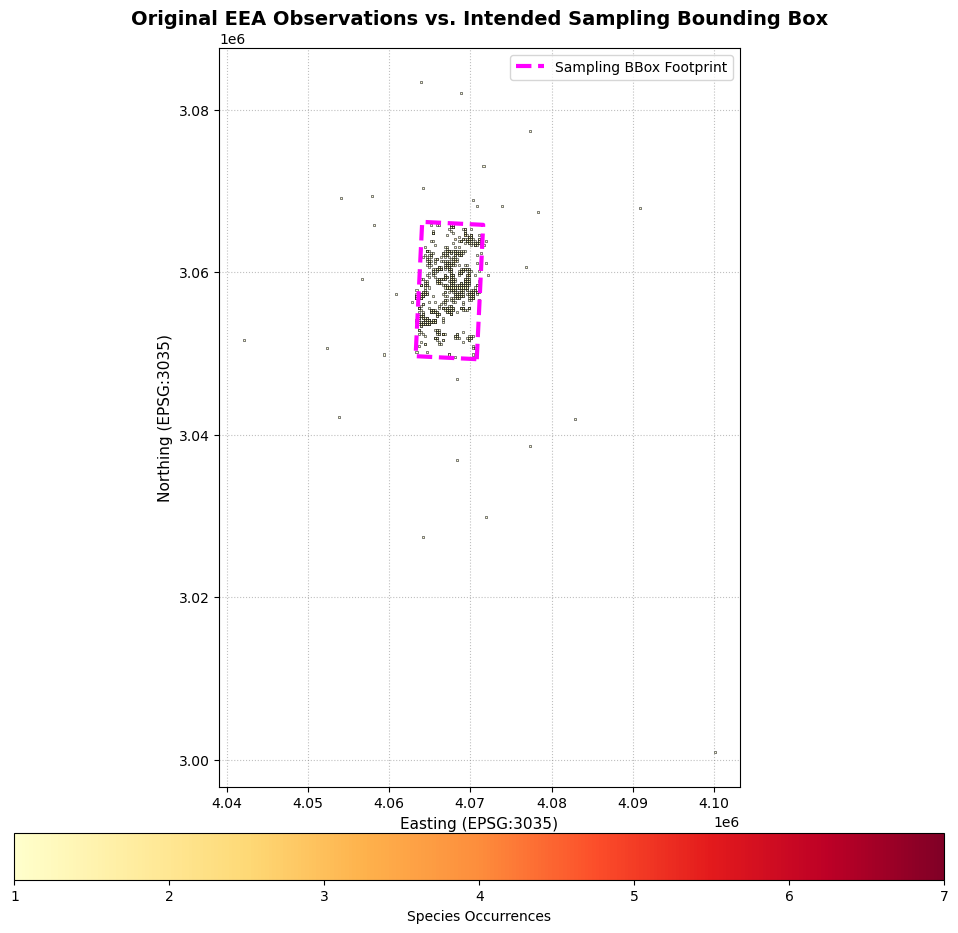

In [138]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box

# 1. Define your original WGS84 bounding box
bbox = [6.365693, 50.50134, 6.472005, 50.650193]

# 2. Convert the bounding box into a GeoDataFrame in its native CRS (WGS84)
bbox_geometry = box(bbox[0], bbox[1], bbox[2], bbox[3])
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_geometry], crs="EPSG:4326")

# 3. Reproject the bounding box to match the EEA grid (EPSG:3035)
bbox_eea = bbox_gdf.to_crs("EPSG:3035")

# 4. Set up the visualization
fig, ax = plt.subplots(figsize=(12, 12))

# Plot all original observations (including outliers)
gdf.plot(
    ax=ax,
    column='occurrences',
    cmap='YlOrRd',
    edgecolor='black',
    linewidth=0.5,
    alpha=0.7,
    legend=True,
    legend_kwds={'label': "Species Occurrences", 'orientation': "horizontal", 'pad': 0.05}
)

# Plot the original sampling bounding box as a bold, dashed perimeter
bbox_eea.plot(
    ax=ax,
    facecolor='none',
    edgecolor='magenta',  # High contrast color
    linewidth=3,
    linestyle='--',
    label='Original Sampling BBox'
)

# 5. Formatting adjustments
ax.set_title("Original EEA Observations vs. Intended Sampling Bounding Box", fontsize=14, fontweight='bold')
ax.set_xlabel("Easting (EPSG:3035)", fontsize=11)
ax.set_ylabel("Northing (EPSG:3035)", fontsize=11)
ax.grid(True, linestyle=':', alpha=0.5, color='gray')

# Add a manual legend handle for the bbox line
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='magenta', lw=3, linestyle='--', label='Sampling BBox Footprint')]
ax.legend(handles=legend_elements, loc='upper right')

plt.show()

In [84]:
import math
import numpy as np
import xarray as xr
from bmc.engine import spatial

spatial_engine = spatial.spatial_engine()

def create_aligned_raster_template(sample_bbox, grid_name, registry=spatial_engine.GRID_REGISTRY):
    """
    Takes a bounding box and generates an empty xarray DataArray that perfectly 
    aligns with the specified master grid from the registry.
    """
    master = registry[grid_name]
    res = master["resolution"]
    master_minx, master_miny, master_maxx, master_maxy = master["bounds"]
    
    # sample_bbox is (minx, miny, maxx, maxy)
    s_minx, s_miny, s_maxx, s_maxy = sample_bbox
    
    # 1. Snap to the Master Grid
    aligned_minx = master_minx + math.floor((s_minx - master_minx) / res) * res
    aligned_miny = master_miny + math.floor((s_miny - master_miny) / res) * res
    aligned_maxx = master_minx + math.ceil((s_maxx - master_minx) / res) * res
    aligned_maxy = master_miny + math.ceil((s_maxy - master_miny) / res) * res
    
    # 2. Calculate dimensions of this local raster (using round to prevent truncation of .999999 cases)
    width = int(round((aligned_maxx - aligned_minx) / res))
    height = int(round((aligned_maxy - aligned_miny) / res))
    
    # 3. Generate spatial coordinates (using pixel centers)
    # By using np.arange on the integer dimension sizes and multiplying by resolution, 
    # we mathematically force the coordinate arrays to be the exact same length as width/height.
    x_coords = aligned_minx + (np.arange(width) + 0.5) * res
    y_coords = aligned_maxy - (np.arange(height) + 0.5) * res
    
    # 4. Create an empty xarray template
    template = xr.DataArray(
        data=np.zeros((height, width), dtype=np.int32), 
        coords={"y": y_coords, "x": x_coords},
        dims=("y", "x"),
        attrs={"crs": master["crs"], "res": res}
    )
    
    return template, (aligned_minx, aligned_miny, aligned_maxx, aligned_maxy)

In [80]:
from pyproj import Transformer

def transform_bbox(bbox, bbox_crs, target_crs):
    # Set up a transformer (always_xy=True ensures Longitude=X, Latitude=Y)
    transformer = Transformer.from_crs(bbox_crs, target_crs, always_xy=True)

    # Transform the lower-left (min) and upper-right (max) corners
    minx, miny = transformer.transform(bbox[0], bbox[1])
    maxx, maxy = transformer.transform(bbox[2], bbox[3])

    return [minx, miny, maxx, maxy]

bbox_projected = transform_bbox(bbox, "EPSG:4326", "EPSG:3035")
#template, box_bounds = create_aligned_raster_template(bbox_projected, "EEA_250m")

In [114]:
# 2. Build the WGS84 template normally
wsg84_template, _ = create_aligned_raster_template(bbox, "Global_WGS84_7_5sec", registry=spatial_engine.GRID_REGISTRY)

# 3. Use the engine to generate a densified, buffered EEA bounding box
eea_bbox = spatial_engine.build_safe_fetch_envelope(
    target_grid_name="Global_WGS84_7_5sec",
    target_bounds=bbox,
    source_crs_or_grid="EEA_250m",
    pixel_buffer=2  # Pads the boundary by 2 pixels to guarantee no edge starvation
)
eea_template, _ = create_aligned_raster_template(eea_bbox, "EEA_250m", registry=spatial_engine.GRID_REGISTRY)

# 4. Do the same for the Global Equal Area template
gea_bbox = spatial_engine.build_safe_fetch_envelope(
    target_grid_name="Global_WGS84_7_5sec",
    target_bounds=bbox,
    source_crs_or_grid="Global_EqualArea_250m",
    pixel_buffer=2
)
gea_template, _ = create_aligned_raster_template(gea_bbox, "Global_EqualArea_250m", registry=spatial_engine.GRID_REGISTRY)

Computing safe fetch envelope for target grid 'Global_WGS84_7_5sec'...
Safe Source Envelope (EPSG:3035): (4062762.36385, 3048797.40232, 4072085.73516, 3066706.62432)
Computing safe fetch envelope for target grid 'Global_WGS84_7_5sec'...
Safe Source Envelope (EPSG:6933): (613702.03879, 5654771.97644, 624959.68822, 5667928.42431)


In [115]:
wsg84_template

<xarray.DataArray (y: 73, x: 52)> Size: 15kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(73, 52), dtype=int32)
Coordinates:
  * y        (y) float64 584B 50.65 50.65 50.65 50.64 ... 50.51 50.51 50.5 50.5
  * x        (x) float64 416B 6.366 6.368 6.37 6.372 ... 6.466 6.468 6.47 6.472
Attributes:
    crs:      EPSG:4326
    res:      0.0020833333333333333

In [116]:
eea_template

<xarray.DataArray (y: 72, x: 38)> Size: 11kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(72, 38), dtype=int32)
Coordinates:
  * y        (y) float64 576B 3.067e+06 3.066e+06 ... 3.049e+06 3.049e+06
  * x        (x) float64 304B 4.063e+06 4.063e+06 ... 4.072e+06 4.072e+06
Attributes:
    crs:      EPSG:3035
    res:      250

In [117]:
gea_template

<xarray.DataArray (y: 53, x: 46)> Size: 10kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(53, 46), dtype=int32)
Coordinates:
  * y        (y) float64 424B 5.668e+06 5.668e+06 ... 5.655e+06 5.655e+06
  * x        (x) float64 368B 6.136e+05 6.138e+05 ... 6.246e+05 6.248e+05
Attributes:
    crs:      EPSG:6933
    res:      250

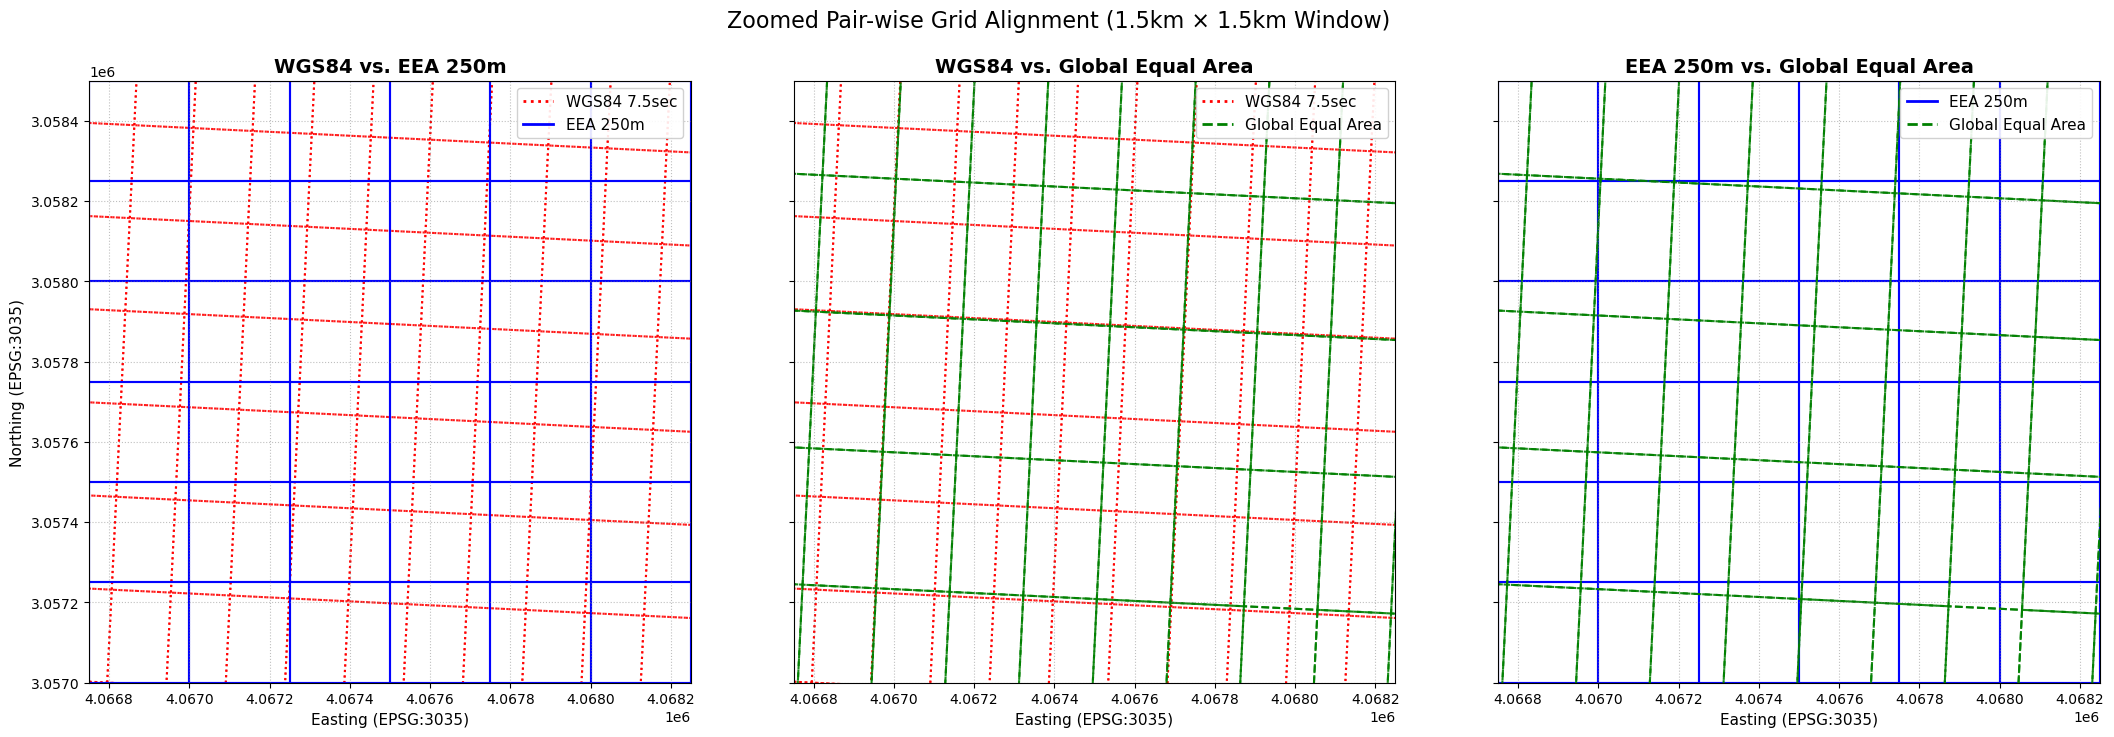

In [118]:
import numpy as np
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def template_to_grid_gdf(template):
    """
    Converts an empty xarray template into a GeoDataFrame of individual grid cell polygons.
    """
    x_centers = template.x.values
    y_centers = template.y.values
    res = template.attrs['res']
    crs = template.attrs['crs']
    
    polygons = []
    
    # Calculate exact cell boundaries based on the pixel centers
    for xi in x_centers:
        for yi in y_centers:
            # Box takes: minx, miny, maxx, maxy
            polygons.append(box(
                xi - (res / 2), 
                yi - (res / 2), 
                xi + (res / 2), 
                yi + (res / 2)
            ))
            
    return gpd.GeoDataFrame(geometry=polygons, crs=crs)

# 2. Convert all three templates into spatial polygon grids
gdf_wgs84 = template_to_grid_gdf(wsg84_template)
gdf_eea = template_to_grid_gdf(eea_template)
gdf_gea = template_to_grid_gdf(gea_template)

# 3. Transform them all to a common projection (EPSG:3035)
common_crs = "EPSG:3035"
gdf_wgs84_proj = gdf_wgs84.to_crs(common_crs)
gdf_eea_proj = gdf_eea.to_crs(common_crs)
gdf_gea_proj = gdf_gea.to_crs(common_crs)

center_x = (4063250 + 4071750) / 2  # ~4067500
center_y = (3049500 + 3066000) / 2  # ~3057750
zoom_buffer = 750  # 750 meters around the center (1.5km total window)

xlims = (center_x - zoom_buffer, center_x + zoom_buffer)
ylims = (center_y - zoom_buffer, center_y + zoom_buffer)

# 2. Setup the subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharex=True, sharey=True)

plots_config = [
    {
        "ax": axes[0],
        "title": "WGS84 vs. EEA 250m",
        "grids": [(gdf_wgs84_proj, 'red', ':', 'WGS84 7.5sec'), 
                  (gdf_eea_proj, 'blue', '-', 'EEA 250m')]
    },
    {
        "ax": axes[1],
        "title": "WGS84 vs. Global Equal Area",
        "grids": [(gdf_wgs84_proj, 'red', ':', 'WGS84 7.5sec'), 
                  (gdf_gea_proj, 'green', '--', 'Global Equal Area')]
    },
    {
        "ax": axes[2],
        "title": "EEA 250m vs. Global Equal Area",
        "grids": [(gdf_eea_proj, 'blue', '-', 'EEA 250m'), 
                  (gdf_gea_proj, 'green', '--', 'Global Equal Area')]
    }
]

for config in plots_config:
    ax = config["ax"]
    custom_lines = []
    
    for gdf, color, linestyle, label in config["grids"]:
        # Setting a higher zorder and slightly thicker lines for clarity
        gdf.plot(ax=ax, facecolor='none', edgecolor=color, linewidth=1.5, linestyle=linestyle, alpha=0.9)
        custom_lines.append(Line2D([0], [0], color=color, lw=2, linestyle=linestyle, label=label))
        
    ax.set_title(config["title"], fontsize=14, fontweight='bold')
    ax.legend(handles=custom_lines, loc='upper right', fontsize=11, framealpha=0.9)
    ax.set_xlabel("Easting (EPSG:3035)", fontsize=11)
    
    # Apply the tight spatial crop
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)
    
    # Keep structural grid lines visible to guide the eye
    ax.grid(True, linestyle=':', alpha=0.5, color='gray')

axes[0].set_ylabel("Northing (EPSG:3035)", fontsize=11)
fig.suptitle("Zoomed Pair-wise Grid Alignment (1.5km × 1.5km Window)", fontsize=16, y=1.02)
plt.tight_layout()

plt.show()

In [132]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
from scipy.spatial import KDTree

def transform_data_to_template(source_gdf, target_template, value_column, data_type='continuous'):
    """
    Transforms data from a source GeoDataFrame to align perfectly with a target 
    xarray.DataArray template. Uses KDTree snapping for discrete data to guarantee 
    100% mass conservation and integer purity.
    """
    # 1. Extract metadata from the xarray template
    if 'crs' not in target_template.attrs or 'res' not in target_template.attrs:
        raise ValueError("Target template must have 'crs' and 'res' in its .attrs dictionary.")
        
    target_crs = target_template.attrs['crs']
    res = target_template.attrs['res']
    x_centers = target_template.x.values
    y_centers = target_template.y.values

    # 2. Build the target grid mesh (Row-major order matching xarray)
    polygons = []
    grid_ids = []
    idx = 0
    for yi in y_centers:
        for xi in x_centers:
            polygons.append(box(
                xi - (res / 2), 
                yi - (res / 2), 
                xi + (res / 2), 
                yi + (res / 2)
            ))
            grid_ids.append(idx)
            idx += 1
            
    target_grid_gdf = gpd.GeoDataFrame({'grid_id': grid_ids}, geometry=polygons, crs=target_crs)

    # 3. Handle Auto-Reprojection
    if source_gdf.crs != target_crs:
        source_projected = source_gdf.to_crs(target_crs)
    else:
        source_projected = source_gdf.copy()

    # --- STRATEGY 1: CONTINUOUS DATA (Areal Weighting) ---
    if data_type == 'continuous':
        source_projected['src_uid'] = source_projected.index
        source_projected['source_area'] = source_projected.geometry.area
        
        intersections = gpd.overlay(source_projected, target_grid_gdf, how='intersection')
        if intersections.empty:
            target_grid_gdf[value_column] = 0.0
            return target_grid_gdf
            
        intersections['intersect_area'] = intersections.geometry.area
        intersections['total_seen_area'] = intersections.groupby('src_uid')['intersect_area'].transform('sum')
        intersections['weight'] = intersections['intersect_area'] / intersections['total_seen_area']
        intersections['weighted_val'] = intersections[value_column] * intersections['weight']
        
        aggregated_values = intersections.groupby('grid_id')['weighted_val'].sum()
        target_grid_gdf = target_grid_gdf.join(aggregated_values, on='grid_id')
        target_grid_gdf[value_column] = target_grid_gdf['weighted_val'].fillna(0)
        target_grid_gdf = target_grid_gdf.drop(columns=['weighted_val'])

    # --- STRATEGY 2: DISCRETE DATA (KDTree Distance Snapping) ---
    elif data_type == 'discrete':
        # Extract source centroids
        src_centroids = source_projected.geometry.centroid
        src_coords = np.column_stack([src_centroids.x, src_centroids.y])
        
        # Build target coordinates array matching the exact row-major index order of target_grid_gdf
        tgt_coords = np.array([[xi, yi] for yi in y_centers for xi in x_centers])
        
        # Build the KDTree and query every source cell against it
        tree = KDTree(tgt_coords)
        _, matched_grid_ids = tree.query(src_coords)
        
        # Assign the matched IDs directly back to a temporary column
        source_projected['assigned_grid_id'] = matched_grid_ids
        
        # Group by the target cell ID and sum the discrete occurrence integers
        aggregated_values = source_projected.groupby('assigned_grid_id')[value_column].sum()
        
        # Merge the sums back to the master output mesh
        target_grid_gdf = target_grid_gdf.join(aggregated_values, on='grid_id')
        target_grid_gdf[value_column] = target_grid_gdf[value_column].fillna(0).astype(int)
            
    else:
        raise ValueError("Invalid data_type. Choose either 'continuous' or 'discrete'.")

    return target_grid_gdf

In [133]:
wgs84_mapped_gdf = transform_data_to_template(
    source_gdf=gdf, 
    target_template=wsg84_template, 
    value_column='occurrences', 
    data_type='discrete'
)

# Map discrete observer flags to the Global Equal Area template
gea_mapped_gdf = transform_data_to_template(
    source_gdf=gdf, 
    target_template=gea_template, 
    value_column='occurrences', 
    data_type='discrete'
)

C:\Users\niels\AppData\Local\Temp\ipykernel_33208\3243304461.py:68: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  src_centroids = source_projected.geometry.centroid


In [134]:
print(gdf["occurrences"].unique(), gdf["occurrences"].sum())
print(wgs84_mapped_gdf["occurrences"].unique(), wgs84_mapped_gdf["occurrences"].sum())
print(gea_mapped_gdf["occurrences"].unique(), gea_mapped_gdf["occurrences"].sum())

[1 2 3 4 7 5 6] 1702
[  4   0   1   3   2   5  10  20  19   6   9   8  35  29   7  25  26  22
 291  53  11  45  21  17  14  12  13  15] 1702
[  3   0   1   4   2   5   6  22  20  12   7  17   9  37  33   8  19  25
  30  11 293  61  39  21  14  13  10  15] 1702


C:\Users\niels\AppData\Local\Temp\ipykernel_33208\2562397856.py:44: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  zeros.plot(


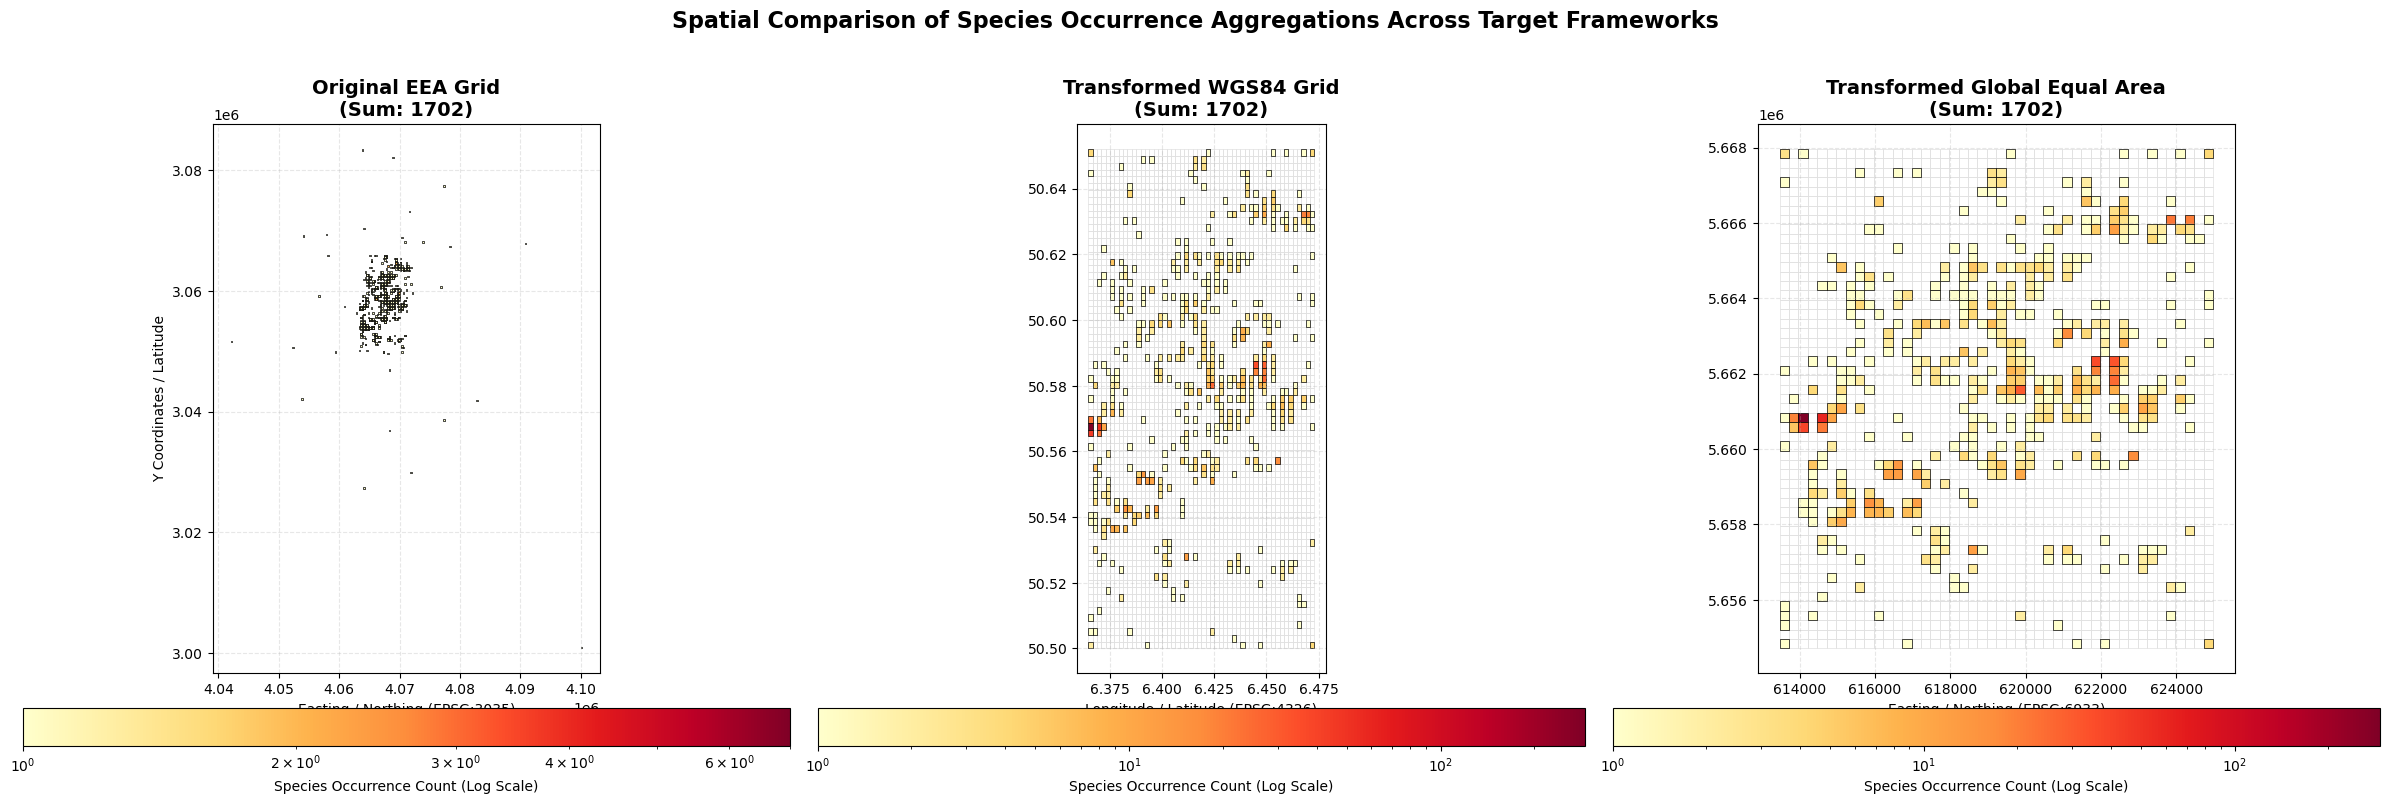

In [135]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import geopandas as gpd

# Assuming 'gdf' is your original source data, 
# and 'wgs84_mapped_gdf' & 'gea_mapped_gdf' are your outputs from the KDTree function.

# 1. Set up a 1x3 subplot figure to compare the distributions
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Configuration dictionary for clear looping
map_configs = [
    {
        "ax": axes[0],
        "gdf": gdf,
        "title": f"Original EEA Grid\n(Sum: {gdf['occurrences'].sum()})",
        "label": "Easting / Northing (EPSG:3035)"
    },
    {
        "ax": axes[1],
        "gdf": wgs84_mapped_gdf,
        "title": f"Transformed WGS84 Grid\n(Sum: {wgs84_mapped_gdf['occurrences'].sum()})",
        "label": "Longitude / Latitude (EPSG:4326)"
    },
    {
        "ax": axes[2],
        "gdf": gea_mapped_gdf,
        "title": f"Transformed Global Equal Area\n(Sum: {gea_mapped_gdf['occurrences'].sum()})",
        "label": "Easting / Northing (EPSG:6933)"
    }
]

# 2. Loop through and plot each GeoDataFrame
for config in map_configs:
    ax = config["ax"]
    dataframe = config["gdf"]
    
    # We create a mask to separate zero cells from actual observations
    # This prevents '0' from skewing our colormap
    zeros = dataframe[dataframe['occurrences'] == 0]
    observations = dataframe[dataframe['occurrences'] > 0]
    
    # Plot the background grid cells with 0 occurrences as light gray lines
    zeros.plot(
        ax=ax, 
        facecolor='none', 
        edgecolor='#E0E0E0', 
        linewidth=0.5
    )
    
    # Plot the actual data hotspots using a Logarithmic scale 
    # This ensures values like 1-5 are still visible alongside values like 293
    if not observations.empty:
        observations.plot(
            ax=ax,
            column='occurrences',
            cmap='YlOrRd',
            linewidth=0.5,
            edgecolor='black',
            legend=True,
            norm=LogNorm(vmin=1, vmax=dataframe['occurrences'].max()),
            legend_kwds={'label': "Species Occurrence Count (Log Scale)", 'orientation': "horizontal", 'pad': 0.05}
        )
        
    # Formatting details
    ax.set_title(config["title"], fontsize=14, fontweight='bold')
    ax.set_xlabel(config["label"], fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)

# 3. Apply global titles and layout cleanups
axes[0].set_ylabel("Y Coordinates / Latitude", fontsize=10)
fig.suptitle("Spatial Comparison of Species Occurrence Aggregations Across Target Frameworks", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Display the map
plt.show()

In [ ]:
print(gdf["occurrences"].unique(), gdf["occurrences"].sum())
wgs84_mapped_gdf["occurrences"].unique()

array([0., 1., 2., 3., 6.])

In [ ]:
print(gdf["occurrences"].unique(), gdf["occurrences"].sum())
gea_mapped_gdf["occurrences"].unique()

array([0., 1., 2., 3., 4.])

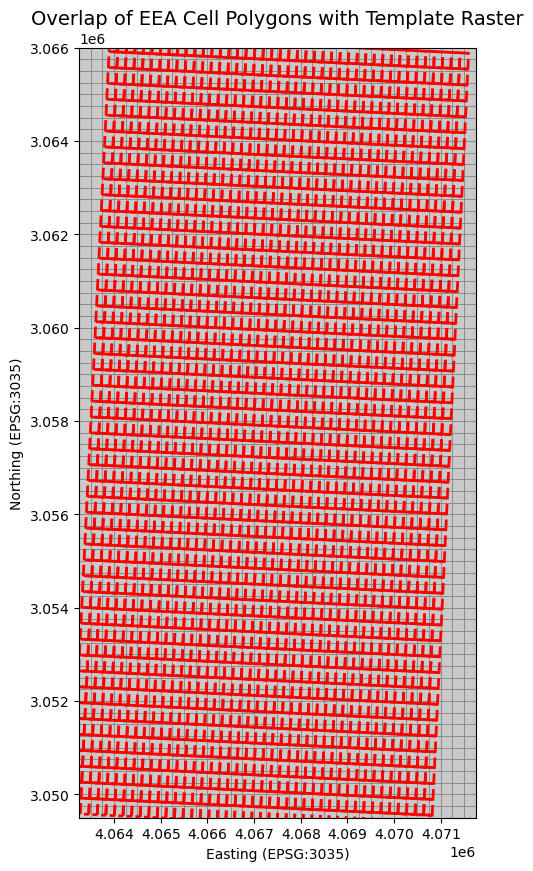

In [95]:
import matplotlib.pyplot  as plt

fig, ax = plt.subplots(figsize=(12, 10))

# 2. Plot the raster template
# We use pcolormesh via xarray's plot method to draw grid lines (edgecolor) 
# and make it slightly transparent (alpha)
template.plot(
    ax=ax, 
    cmap='Greys',       # Subtle background color
    alpha=0.5,          # Transparency
    edgecolor='gray',   # Shows the raster grid cell boundaries
    linewidth=0.5,
    add_colorbar=False  # Optional: turn off if it's just a template of zeros
)

# 3. Plot the GeoDataFrame polygons over the raster
# We use 'none' for facecolor so it doesn't obscure the raster beneath it
gdf.plot(
    ax=ax,
    facecolor='none', 
    edgecolor='red',    # High contrast color for visibility
    linewidth=2,
    linestyle='--'      # Dashed line helps distinguish it from raster gridlines
)

# 4. Format the map for better readability
ax.set_title("Overlap of EEA Cell Polygons with Template Raster", fontsize=14)
ax.set_xlabel("Easting (EPSG:3035)")
ax.set_ylabel("Northing (EPSG:3035)")
ax.grid(False) # Turn off matplotlib's standard grid to avoid visual clutter

# Display the plot
plt.show()

In [77]:
import numpy as np

def check_grid_alignment(gdf, raster, resolution=250):
    """
    Checks if a GeoDataFrame's polygons align perfectly with a raster's grid.
    """
    print("--- Alignment Diagnostic Report ---")
    
    # 1. Check Polygon Drift
    # Extract the lower-left coordinates (minx, miny) for all polygons
    bounds = gdf.bounds
    poly_minx = bounds['minx'].values
    poly_miny = bounds['miny'].values
    
    # Calculate how far off the polygons are from a pure 250m interval
    x_drift = np.abs(poly_minx % resolution)
    y_drift = np.abs(poly_miny % resolution)
    
    # Account for modulo wrap-around (e.g., a drift of 249.999 is actually a drift of -0.001)
    x_drift = np.minimum(x_drift, resolution - x_drift)
    y_drift = np.minimum(y_drift, resolution - y_drift)
    
    max_poly_x_drift = np.max(x_drift)
    max_poly_y_drift = np.max(y_drift)
    
    if np.isclose(max_poly_x_drift, 0, atol=1e-6) and np.isclose(max_poly_y_drift, 0, atol=1e-6):
        print("Polygons: Perfectly snapped to the 250m grid (No drift detected).")
    else:
        print(f"Polygons: Drift detected! Max X drift: {max_poly_x_drift}m, Max Y drift: {max_poly_y_drift}m")

    # 2. Check Raster Grid Drift
    # Extract the first x and y coordinates from the raster
    rx = raster.x.values[0]
    ry = raster.y.values[0]
    
    # Determine if raster coords represent edges (remainder 0) or pixel centers (remainder 125)
    rx_rem = rx % resolution
    
    if np.isclose(rx_rem, 0, atol=1e-6):
        print("Raster: Coordinates represent pixel EDGES and are aligned.")
        raster_is_aligned = True
    elif np.isclose(rx_rem, resolution / 2, atol=1e-6):
        print("Raster: Coordinates represent pixel CENTERS and are aligned.")
        raster_is_aligned = True
    else:
        print(f"Raster: Sub-pixel drift detected in the template raster! Offset: {rx_rem}m")
        raster_is_aligned = False
        
    # 3. Final Conclusion
    if np.isclose(max_poly_x_drift, 0, atol=1e-6) and raster_is_aligned:
        print("\n 1-to-1 Match Confirmed. No drift between datasets.")
    else:
        print("\n Misalignment detected. Do not proceed with rasterization without fixing the grid origins.")

# Run the diagnostic (assuming your variables are named 'gdf' and 'template_raster')
check_grid_alignment(gdf, template, resolution=250)

--- Alignment Diagnostic Report ---
Polygons: Perfectly snapped to the 250m grid (No drift detected).
Raster: Coordinates represent pixel CENTERS and are aligned.

 1-to-1 Match Confirmed. No drift between datasets.


In [31]:
import geopandas as gpd

# 1. Apply your custom parsing function to build the geometries
gbif_table['geometry'] = gbif_table['eeacellcode'].apply(harmonisation.parse_to_polygon)

# 2. Convert to a GeoDataFrame using the Master CRS
gdf = gpd.GeoDataFrame(gbif_table, geometry='geometry', crs="EPSG:3035")
gdf

,scientificname,year,month,day,countrycode,eeacellcode,occurrences,distinctobservers,geometry
0,"Limnephilus Leach, 1815",2024,11,2,DE,250mE406950N306375,1,1,"POLYGON ((4069750 3063750, 4069750 3064000, 40..."
1,Lycaenidae,2020,6,20,DE,250mE406450N305425,1,1,"POLYGON ((4064750 3054250, 4064750 3054500, 40..."
2,"Tischeria ekebladella (Bjerkander, 1795)",2024,9,18,DE,250mE407125N306375,1,1,"POLYGON ((4071500 3063750, 4071500 3064000, 40..."
3,"Potamophylax Wallengren, 1891",2021,8,22,DE,250mE406350N305700,1,1,"POLYGON ((4063750 3057000, 4063750 3057250, 40..."
4,"Cabera exanthemata (Scopoli, 1763)",2023,6,4,DE,250mE406525N305500,1,1,"POLYGON ((4065500 3055000, 4065500 3055250, 40..."
...,...,...,...,...,...,...,...,...,...
1590,"Vespa Linnaeus, 1758",2020,5,29,DE,250mE406750N305475,1,1,"POLYGON ((4067750 3054750, 4067750 3055000, 40..."
1591,"Acronicta tridens (Denis & Schiffermüller) , 1775",2022,7,18,DE,250mE406350N305700,1,1,"POLYGON ((4063750 3057000, 4063750 3057250, 40..."
1592,Sericostomatidae,2021,9,16,DE,250mE406350N305675,1,1,"POLYGON ((4063750 3056750, 4063750 3057000, 40..."
1593,"Halesus Stephens, 1836",2021,9,16,DE,250mE406350N305725,1,1,"POLYGON ((4063750 3057250, 4063750 3057500, 40..."


In [46]:
def fetch_col_id(scientific_name, DATASET_KEY = "7ddf754f-d193-4cc9-b351-99906754a03b"):
    """
    Safely queries GBIF for a single name and extracts the native CoL taxonID.
    """
    try:
        # We use limit=1 because we only care about the top match to save bandwidth
        search_results = pygbif.species.name_lookup(
            q=scientific_name, 
            datasetKey=DATASET_KEY,
            limit=1
        )
        
        # Safely drill down into the JSON payload
        if search_results and search_results.get('results'):
            first_record = search_results['results'][0]
            return first_record.get('taxonID')  # Returns the CoL ID (or None if missing)
            
    except Exception as e:
        print(f"Network error on {scientific_name}: {e}")
        
    return None

def fetch_usageKey(scientific_name):
    """
    Queries the GBIF Backbone Taxonomy to find the master usageKey using API v2.
    """
    try:
        match = pygbif.species.name_backbone(scientificName=scientific_name)
        
        # 1. New API v2 Structure (Extract from the 'usage' block)
        if match and 'usage' in match:
            # The ID is typically stored under 'key' in the usage dict
            return match['usage'].get('key')
            
        # 2. Old API v1 fallback (Just in case)
        elif match:
            return match.get('usageKey')
            
    except Exception as e:
        print(f"Network error on {scientific_name}: {e}")
        
    return None

In [33]:
# Extract only the unique names (e.g., reduces 1600 API calls down to maybe 300)
unique_names = gdf["scientificname"].dropna().unique()

print(f"Fetching CoL IDs for {len(unique_names)} unique taxa...")

# Build a translation dictionary
id_mapping = {}
for name in unique_names:
    id_mapping[name] = fetch_col_id(name)

# 3. Map the dictionary back to the main DataFrame
gdf["colID"] = gdf["scientificname"].map(id_mapping)

gdf

Fetching CoL IDs for 518 unique taxa...


,scientificname,year,month,day,countrycode,eeacellcode,occurrences,distinctobservers,geometry,colID
0,"Limnephilus Leach, 1815",2024,11,2,DE,250mE406950N306375,1,1,"POLYGON ((4069750 3063750, 4069750 3064000, 40...",NaN
1,Lycaenidae,2020,6,20,DE,250mE406450N305425,1,1,"POLYGON ((4064750 3054250, 4064750 3054500, 40...",C98
2,"Tischeria ekebladella (Bjerkander, 1795)",2024,9,18,DE,250mE407125N306375,1,1,"POLYGON ((4071500 3063750, 4071500 3064000, 40...",577L5
3,"Potamophylax Wallengren, 1891",2021,8,22,DE,250mE406350N305700,1,1,"POLYGON ((4063750 3057000, 4063750 3057250, 40...",6V6S
4,"Cabera exanthemata (Scopoli, 1763)",2023,6,4,DE,250mE406525N305500,1,1,"POLYGON ((4065500 3055000, 4065500 3055250, 40...",5X5JK
...,...,...,...,...,...,...,...,...,...,...
1590,"Vespa Linnaeus, 1758",2020,5,29,DE,250mE406750N305475,1,1,"POLYGON ((4067750 3054750, 4067750 3055000, 40...",CCC25
1591,"Acronicta tridens (Denis & Schiffermüller) , 1775",2022,7,18,DE,250mE406350N305700,1,1,"POLYGON ((4063750 3057000, 4063750 3057250, 40...",NaN
1592,Sericostomatidae,2021,9,16,DE,250mE406350N305675,1,1,"POLYGON ((4063750 3056750, 4063750 3057000, 40...",G8F
1593,"Halesus Stephens, 1836",2021,9,16,DE,250mE406350N305725,1,1,"POLYGON ((4063750 3057250, 4063750 3057500, 40...",62TPW


In [47]:
print(f"Fetching usageKey for {len(unique_names)} unique taxa...")

# Build a translation dictionary
id_mapping = {}
for name in unique_names:
    id_mapping[name] = fetch_usageKey(name)

# 3. Map the dictionary back to the main DataFrame
gdf["usageKey"] = gdf["scientificname"].map(id_mapping)

gdf

Fetching usageKey for 518 unique taxa...


,scientificname,year,month,day,countrycode,eeacellcode,occurrences,distinctobservers,geometry,colID,usageKey
0,"Limnephilus Leach, 1815",2024,11,2,DE,250mE406950N306375,1,1,"POLYGON ((4069750 3063750, 4069750 3064000, 40...",NaN,1442450
1,Lycaenidae,2020,6,20,DE,250mE406450N305425,1,1,"POLYGON ((4064750 3054250, 4064750 3054500, 40...",C98,5473
2,"Tischeria ekebladella (Bjerkander, 1795)",2024,9,18,DE,250mE407125N306375,1,1,"POLYGON ((4071500 3063750, 4071500 3064000, 40...",577L5,1939432
3,"Potamophylax Wallengren, 1891",2021,8,22,DE,250mE406350N305700,1,1,"POLYGON ((4063750 3057000, 4063750 3057250, 40...",6V6S,1442833
4,"Cabera exanthemata (Scopoli, 1763)",2023,6,4,DE,250mE406525N305500,1,1,"POLYGON ((4065500 3055000, 4065500 3055250, 40...",5X5JK,5143675
...,...,...,...,...,...,...,...,...,...,...,...
1590,"Vespa Linnaeus, 1758",2020,5,29,DE,250mE406750N305475,1,1,"POLYGON ((4067750 3054750, 4067750 3055000, 40...",CCC25,1311334
1591,"Acronicta tridens (Denis & Schiffermüller) , 1775",2022,7,18,DE,250mE406350N305700,1,1,"POLYGON ((4063750 3057000, 4063750 3057250, 40...",NaN,1783016
1592,Sericostomatidae,2021,9,16,DE,250mE406350N305675,1,1,"POLYGON ((4063750 3056750, 4063750 3057000, 40...",G8F,4404
1593,"Halesus Stephens, 1836",2021,9,16,DE,250mE406350N305725,1,1,"POLYGON ((4063750 3057250, 4063750 3057500, 40...",62TPW,1441921


In [57]:
import pandas as pd
import numpy as np
import xarray as xr
import sparse

# 1. Prepare tabular data (Time and Spatial centers)
gdf['time'] = pd.to_datetime(gdf[['year', 'month']].assign(day=1))
gdf['x'] = gdf.geometry.centroid.x
gdf['y'] = gdf.geometry.centroid.y
agg_df = gdf.groupby(['time', 'usageKey', 'y', 'x'])['occurrences'].sum().reset_index()

# 2. Define our Master Axes
# We use the template's exact x and y to ensure it maps perfectly to your master grid
master_times = np.sort(agg_df['time'].unique())
master_species = np.sort(agg_df['usageKey'].unique())
master_y = template.y.values
master_x = template.x.values

# 3. Map tabular values to Integer Indices for the COO format
# pd.Categorical cleanly translates actual values (like "2024-01-01") into integer positions (like 0, 1, 2)
time_idx = pd.Categorical(agg_df['time'], categories=master_times).codes
spec_idx = pd.Categorical(agg_df['usageKey'], categories=master_species).codes
y_idx = pd.Categorical(agg_df['y'], categories=master_y).codes
x_idx = pd.Categorical(agg_df['x'], categories=master_x).codes

# 4. Filter out anything that fell completely outside the master grid
# (Categorical returns -1 for values that aren't in the categories)
valid_mask = (y_idx >= 0) & (x_idx >= 0)

# 5. Build the Sparse Array DIRECTLY
coords = np.vstack([
    time_idx[valid_mask], 
    spec_idx[valid_mask], 
    y_idx[valid_mask], 
    x_idx[valid_mask]
])
data = agg_df['occurrences'].values[valid_mask].astype(np.int32)
shape = (len(master_times), len(master_species), len(master_y), len(master_x))

# Instantly creates a weightless N-dimensional array without allocating empty memory
s_arr = sparse.COO(coords, data, shape=shape)

# 6. Wrap it in xarray for downstream use
da_sparse = xr.DataArray(
    s_arr,
    coords={
        'time': master_times, 
        'usageKey': master_species, 
        'y': master_y, 
        'x': master_x
    },
    dims=['time', 'usageKey', 'y', 'x'],
    name="occurrences",
    attrs=template.attrs
)

C:\Users\niels\AppData\Local\Temp\ipykernel_33208\32818379.py:23: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  y_idx = pd.Categorical(agg_df['y'], categories=master_y).codes
C:\Users\niels\AppData\Local\Temp\ipykernel_33208\32818379.py:24: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  x_idx = pd.Categorical(agg_df['x'], categories=master_x).codes
C:\Users\niels\AppData\Local\Temp\ipykernel_33208\32818379.py:44: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta6

In [58]:
da_sparse

Format,coo
Data Type,int32
Shape,"(49, 516, 66, 34)"
nnz,1473
Density,2.5961758910752462e-05
Read-only,True
Size,17.3K
Storage ratio,0.00
